In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-25 15:32:04--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to cs666.org (cs666.org)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz.2’

mito.npz.2          100%[===================>]  35.87M  89.0MB/s    in 0.4s    

2026-04-25 15:32:05 (89.0 MB/s) - ‘mito.npz.2’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
loaded['arr_0'].shape

(2, 660, 256, 256)

In [7]:
images.shape

(660, 256, 256)

In [8]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [9]:
# TODO: What does the above code do?

## First, we load the data with this shape (2, 660, 256, 256), [0] = images, [1] = masks
## Then, we normalized the image somehow the values are between 0,1.
## and we change the type of data in masks to float (1.0, 0.0)

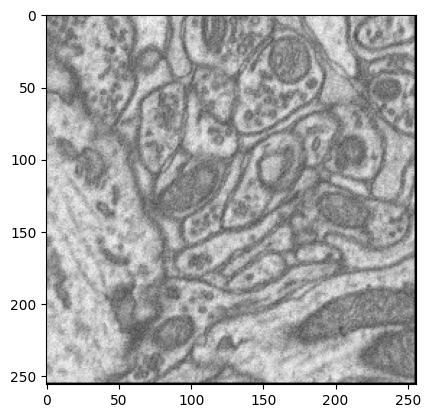

In [10]:
imshow(images[0], cmap='gray')

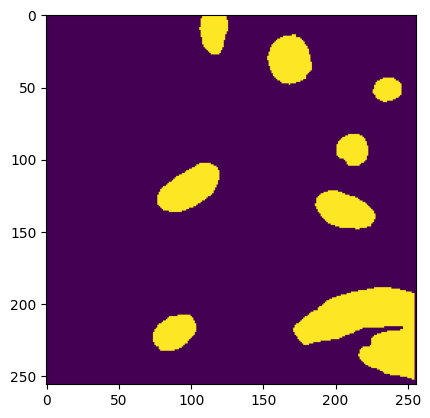

In [11]:
imshow(masks[0])

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [13]:
# TODO: What does the above code do?
# TODO: In here we divide the data to trianing and testing sets. first we divide it to 70% for train, then we divide the remaining to 50,50
## Som over all, we have 70% for training, 15% for validation and 15% for test.

## 2. Make the Data Pytorch-ready! (10 points)

In [14]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [15]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [16]:
# TODO: What does the above code do?
# TODO: This code defines data augmentation transforms using the albumentations library

In [17]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [18]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [19]:
# TODO: What does the above code do?
# TODO: This code wraps the image/mask data into a PyTorch-compatible dataset class 
## and creates data loaders that feed batches to the model during training.

## 3. Configure the Classifier! (30 points)

In [20]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [21]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [23]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [24]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.3507, train_dice=0.6654 | val_loss=1.3444, val_dice=0.1709
Epoch 2/10 | train_loss=0.1480, train_dice=0.8411 | val_loss=0.1372, val_dice=0.8320
Epoch 3/10 | train_loss=0.1021, train_dice=0.8732 | val_loss=0.0776, val_dice=0.9076
Epoch 4/10 | train_loss=0.0773, train_dice=0.8998 | val_loss=0.0783, val_dice=0.8896
Epoch 5/10 | train_loss=0.0700, train_dice=0.9073 | val_loss=0.0684, val_dice=0.9023
Epoch 6/10 | train_loss=0.0586, train_dice=0.9234 | val_loss=0.0532, val_dice=0.9289
Epoch 7/10 | train_loss=0.0531, train_dice=0.9288 | val_loss=0.0466, val_dice=0.9388
Epoch 8/10 | train_loss=0.0498, train_dice=0.9330 | val_loss=0.0504, val_dice=0.9385
Epoch 9/10 | train_loss=0.0495, train_dice=0.9333 | val_loss=0.0440, val_dice=0.9410
Epoch 10/10 | train_loss=0.0428, train_dice=0.9429 | val_loss=0.0370, val_dice=0.9526
Best val dice: 0.9526288764817374


In [25]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

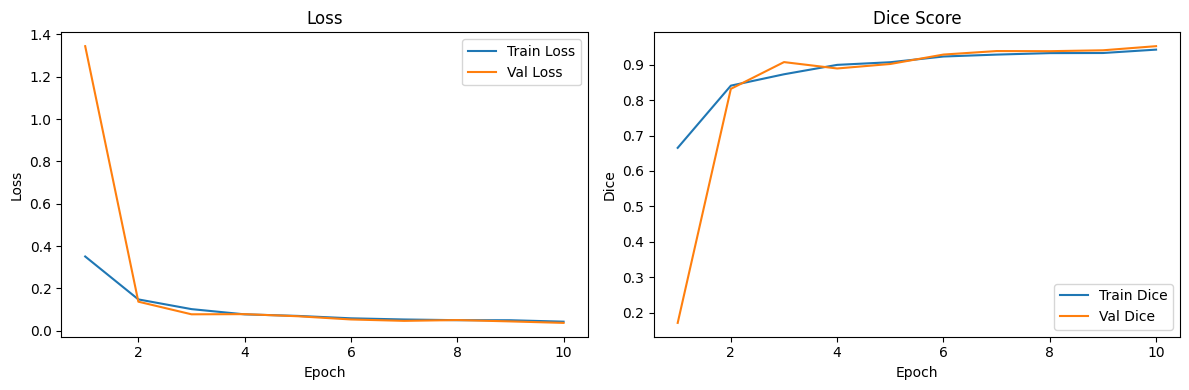

In [26]:
epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses, label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Dice curve
ax2.plot(epochs, train_dices, label='Train Dice')
ax2.plot(epochs, val_dices, label='Val Dice')
ax2.set_title('Dice Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [27]:
# TODO: Do these plots look good?
# TODO: Yes, we can see that the loss of training and validation is decreasing, and in the final epoch, it's very low. Also, the Dice score
# is increasing in both training and validation

## 5. Testing the U-Net. (20 points)

In [28]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0371
Test dice: 0.951


In [29]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

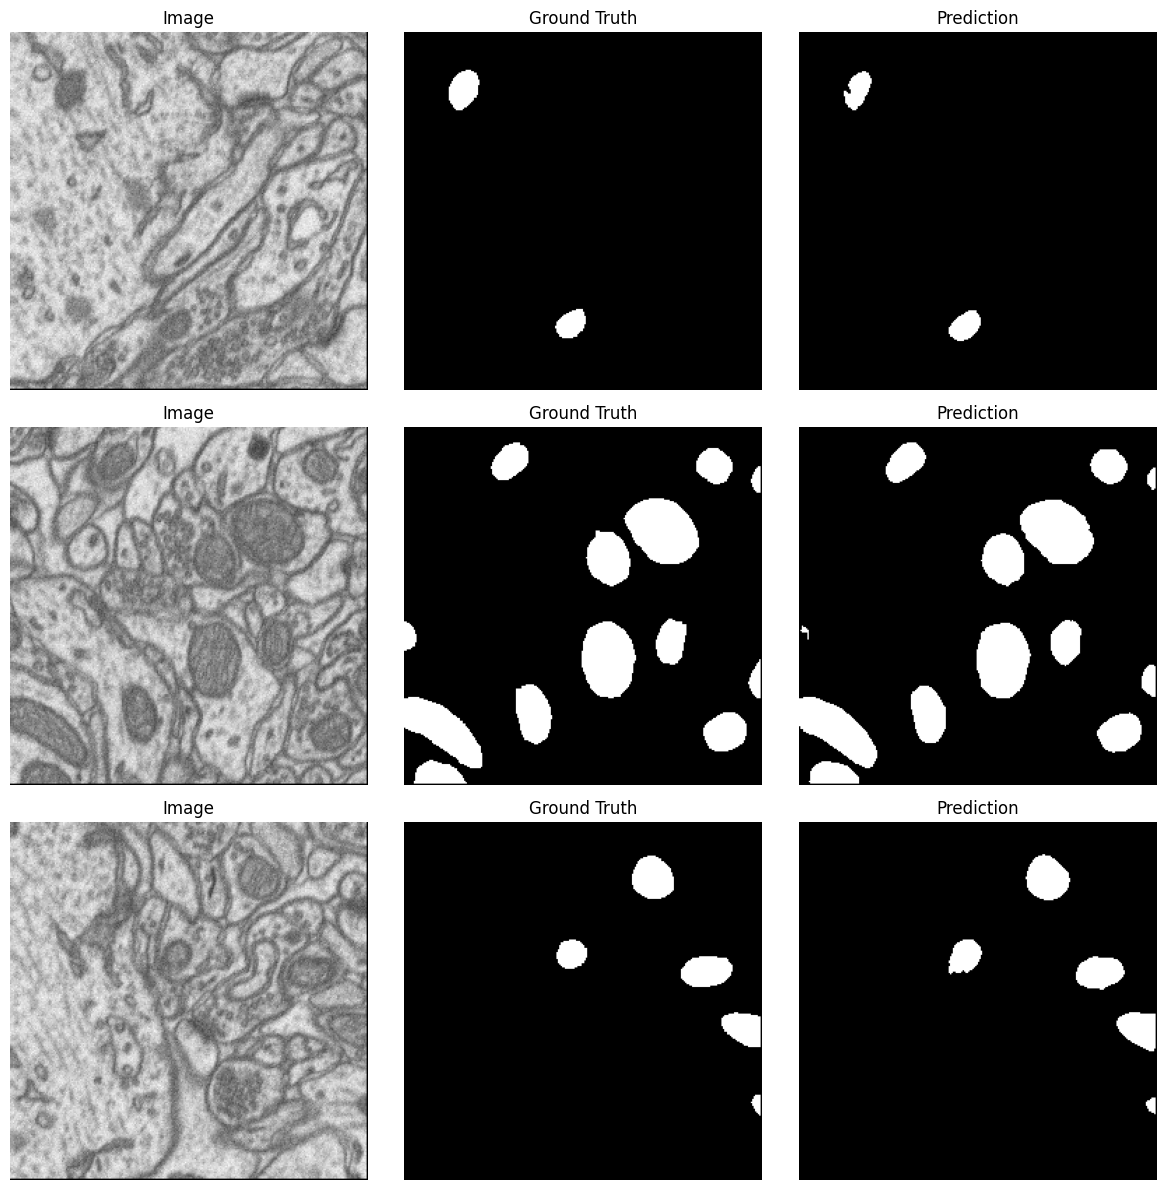

In [30]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [31]:
# TODO: Do you think the classifier works well?
# TODO: It works very well. we can see the pattern and number of white shape in ground truth and prediction are similar. so it works well.

## Bonus: Improve the results. (33 points)

In [32]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: The point is that we can change the encoder to something better, we can use preprocessed weights and increase number of epoches

In [33]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
best_val_dice = 0.0
train_losses, val_losses, train_dices, val_dices = [], [], [], []

In [34]:
num_epochs = 20

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)
    scheduler.step(val_dice)
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_dices.append(train_dice); val_dices.append(val_dice)
    # if val_dice > best_val_dice:
    #     best_val_dice = val_dice
    #     torch.save(model.state_dict(), "best_mito_model_v2.pth")
    print(f"Epoch {epoch+1}/{num_epochs} | train_dice={train_dice:.4f} | val_dice={val_dice:.4f}")

Epoch 1/20 | train_dice=0.5762 | val_dice=0.5938
Epoch 2/20 | train_dice=0.8691 | val_dice=0.8687
Epoch 3/20 | train_dice=0.9045 | val_dice=0.9230
Epoch 4/20 | train_dice=0.9204 | val_dice=0.8572
Epoch 5/20 | train_dice=0.9275 | val_dice=0.9335
Epoch 6/20 | train_dice=0.9308 | val_dice=0.9411
Epoch 7/20 | train_dice=0.9402 | val_dice=0.9444
Epoch 8/20 | train_dice=0.9451 | val_dice=0.9434
Epoch 9/20 | train_dice=0.9475 | val_dice=0.9562
Epoch 10/20 | train_dice=0.9502 | val_dice=0.9468
Epoch 11/20 | train_dice=0.9515 | val_dice=0.9562
Epoch 12/20 | train_dice=0.9531 | val_dice=0.9607
Epoch 13/20 | train_dice=0.9568 | val_dice=0.9570
Epoch 14/20 | train_dice=0.9580 | val_dice=0.9611
Epoch 15/20 | train_dice=0.9592 | val_dice=0.9623
Epoch 16/20 | train_dice=0.9594 | val_dice=0.9394
Epoch 17/20 | train_dice=0.9568 | val_dice=0.9570
Epoch 18/20 | train_dice=0.9589 | val_dice=0.9499
Epoch 19/20 | train_dice=0.9618 | val_dice=0.9639
Epoch 20/20 | train_dice=0.9625 | val_dice=0.9657


In [35]:
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)
print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))
print(f"Improvement: {test_dice - 0.9437:+.4f}")

Test loss: 0.0284
Test dice: 0.9642
Improvement: +0.0205


In [36]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#